# Cross Check and Descriptive Statistics

In [ ]:
!git clone https://github.com/michelle-qyh/SOSC314-Course-Project.git
%cd SOSC314-Course-Project


Cloning into 'SOSC314-Course-Project'...
remote: Enumerating objects: 287, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (99/99), done.
remote: Total 287 (delta 38), reused 3 (delta 0), pack-reused 188 (from 1)
Receiving objects: 100% (287/287), 7.62 MiB | 15.10 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/SOSC314-Course-Project


The code in this file directly use the outputs of "02_build_corpus.py" (does not re-run collection or cleaning). Two checks run before the descriptive summary:
1. **Boilerplate spot-check** — does cleaning perform equally well across institutions, or does residual junk inflate word counts for one of them?
2. **Threshold sensitivity** — how does corpus size respond to the MIN_DOC_WORDS / MIN_DENSITY / MIN_AI_MENTIONS cutoffs in "build_corpus.py"?

In [ ]:

import sys
from pathlib import Path

import pandas as pd
import re

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))

import build_corpus  # noqa: E402
import collect        # noqa: E402

CORPUS = ROOT / "data" / "corpus"
RAW = ROOT / "data" / "raw"

docs = pd.read_parquet(CORPUS / "documents.parquet")
paras = pd.read_parquet(CORPUS / "paragraphs.parquet")
exclusions = pd.read_csv(CORPUS / "exclusions.csv")

print(f"documents: {len(docs)} | paragraphs: {len(paras)} | excluded: {len(exclusions)}")


documents: 134 | paragraphs: 27486 | excluded: 12


In [ ]:
# %%
docs = pd.read_parquet(CORPUS / "documents.parquet")
paras = pd.read_parquet(CORPUS / "paragraphs.parquet")
exclusions = pd.read_csv(CORPUS / "exclusions.csv")

print(f"documents: {len(docs)} | paragraphs: {len(paras)} | excluded: {len(exclusions)}")
print("\ndocuments.parquet columns:", docs.columns.tolist())
print("paragraphs.parquet columns:", paras.columns.tolist())
print(f"\nraw/ folder exists: {RAW.exists()}")

documents: 134 | paragraphs: 27486 | excluded: 12

documents.parquet columns: ['doc_id', 'work', 'institution', 'doc_type', 'genre', 'type_raw', 'date', 'year', 'title', 'mtype', 'fmt', 'n_words', 'n_paragraphs', 'ai_mentions', 'ai_density']
paragraphs.parquet columns: ['doc_id', 'para_idx', 'institution', 'doc_type', 'genre', 'year', 'n_words', 'ai_mentions', 'text']

raw/ folder exists: False


## 1. Boilerplate cleaning spot-check

"BOILERPLATE" in "build_corpus.py" was written primarily against Council routing headers and Commission publication footers. It is not obvious the same patterns catch everything in Parliament documents (resolutions, amendment lists), which carry their own recurring markers — e.g. translation tags ("Or. en"), amendment/justification headers, PE document codes.

Two checks:
(a) check a few before/after examples per institution,
(b) scan "text_clean" for a set of *candidate* residual patterns not in the current BOILERPLATE list, counted by institution.

**(A) Before/ After Examples per Institution**

In [ ]:

for inst in ["Commission", "Parliament", "Council"]:
    sample_ids = docs[docs.institution == inst]["doc_id"].sample(
        n=min(2, (docs.institution == inst).sum()), random_state=0
    )
    for doc_id in sample_ids:
        matches = list(RAW.glob(f"{doc_id}.*"))
        if not matches:
            print(f"[{inst}] {doc_id}: raw file not found, skipping")
            continue
        raw_text = collect.extract(matches[0])
        clean_text = build_corpus.strip_boilerplate(raw_text)
        print(f"\n=== [{inst}] {doc_id} ===")
        print(f"words before: {len(raw_text.split())} | after: {len(clean_text.split())}")
        print("--- first 400 chars after cleaning ---")
        print(clean_text[:400])

[Commission] b397c30e-6a63-11f1-ae88-01aa75ed71a1: raw file not found, skipping
[Commission] baebce15-1ef5-11ed-8fa0-01aa75ed71a1: raw file not found, skipping
[Parliament] 1923c62a-2640-11ec-bd8e-01aa75ed71a1: raw file not found, skipping
[Parliament] ef62dd1f-888e-11ec-8c40-01aa75ed71a1: raw file not found, skipping
[Council] 10220a8a-6fa1-11f1-ae88-01aa75ed71a1: raw file not found, skipping
[Council] e7fdab55-488b-11ef-acbc-01aa75ed71a1: raw file not found, skipping


**(B) Candidate Residual Pattern not currently in Boilerplate**

In [ ]:
def reconstructed_clean_text(doc_id: str) -> str:
    sub = paras[paras.doc_id == doc_id].sort_values("para_idx")
    return "\n\n".join(sub["text"])

for inst in ["Commission", "Parliament", "Council"]:
    sample_ids = docs[docs.institution == inst]["doc_id"].sample(
        n=min(2, (docs.institution == inst).sum()), random_state=0
    )
    for doc_id in sample_ids:
        clean_text = reconstructed_clean_text(doc_id)
        print(f"\n=== [{inst}] {doc_id} ===")
        print(f"words after cleaning (reconstructed): {len(clean_text.split())}")
        print("--- first 400 chars ---")
        print(clean_text[:400] if clean_text else "(no paragraphs found — check doc_id)")


=== [Commission] b397c30e-6a63-11f1-ae88-01aa75ed71a1 ===
words after cleaning (reconstructed): 14902
--- first 400 chars ---
COMMUNICATION FROM THE COMMISSION TO THE EUROPEAN PARLIAMENT, THE COUNCIL, THE EUROPEAN ECONOMIC AND SOCIAL COMMITTEE AND THE COMMITTEE OF THE REGIONS

State of the Digital Decade 2026: Closing structural gaps and mobilising investments for 2030 and beyond

{SWD(2026) 154 final} - {SWD(2026) 155 final} - {SWD(2026) 156 final} - {SWD(2026) 157 final}

In 2026, the EU is facing a combination of long

=== [Commission] baebce15-1ef5-11ed-8fa0-01aa75ed71a1 ===
words after cleaning (reconstructed): 5170
--- first 400 chars ---
authorising the opening of negotiations on behalf of the European Union for a Council of Europe convention on artificial intelligence, human rights, democracy and the rule of law

Artificial intelligence (AI) offers great opportunities for society, the environment and the economy. At the same time, depending on the circumstances regarding its s

Candidate residual patterns not currently in build_corpus. BOILERPLATE (mostly Parliament-specific: amendment lists, translation markers, PE codes). These patterns were NOT written by inspecting build_corpus.BOILERPLATE itself (which targets mainly Council/Commission formats) — they test whether Parliament's distinct document conventions slip through uncleaned.

In [ ]:
CANDIDATE_RESIDUAL = {
    "translation_marker": re.compile(r"(?im)^\s*Or\.\s*[a-z]{2}\s*$"),
    "amendment_header": re.compile(r"(?im)^\s*Amendment\s+\d+\s*$"),
    "justification_header": re.compile(r"(?im)^\s*Justification\s*$"),
    "pe_doc_code": re.compile(r"PE\d{3,4}\.\d{3}v\d{2}-\d{2}"),
    "page_of_pe": re.compile(r"(?im)^\s*\d+/\d+\s+PE\d{3,4}\.\d{3}\s*$"),
}

# Reconstruct clean text per document from paragraphs
docs_clean_text = (paras.sort_values(["doc_id", "para_idx"])
                        .groupby("doc_id")["text"]
                        .apply(lambda s: "\n\n".join(s)))

rows = []
for doc_id, institution in docs[["doc_id", "institution"]].itertuples(index=False):
    text = docs_clean_text.get(doc_id, "")
    for label, pattern in CANDIDATE_RESIDUAL.items():
        n_hits = len(pattern.findall(text))
        if n_hits:
            rows.append({"institution": institution, "doc_id": doc_id,
                        "pattern": label, "hits": n_hits})

residual = pd.DataFrame(rows)
if len(residual):
    print("Residual boilerplate hits by institution and pattern:")
    print(residual.pivot_table(index="institution", columns="pattern",
                               values="hits", aggfunc="sum", fill_value=0))
else:
    print("No hits for the candidate patterns — current BOILERPLATE list looks sufficient.")

No hits for the candidate patterns — current BOILERPLATE list looks sufficient.


# 2. Sensitivity Test

# Descriptive Statistics

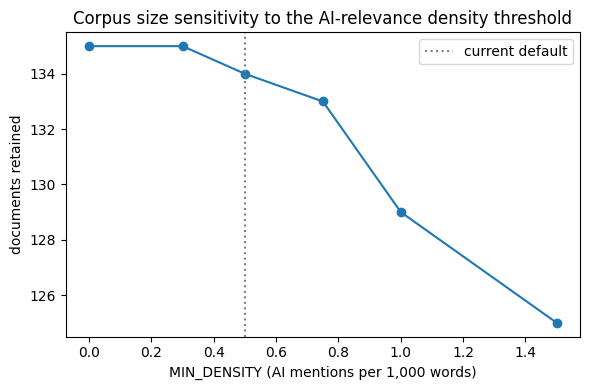

In [ ]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(density_sensitivity.index, density_sensitivity["total"], marker="o")
ax.axvline(CURRENT["min_density"], color="grey", ls=":", label="current default")
ax.set_xlabel("MIN_DENSITY (AI mentions per 1,000 words)")
ax.set_ylabel("documents retained")
ax.set_title("Corpus size sensitivity to the AI-relevance density threshold")
ax.legend()
fig.tight_layout()

(ROOT / "reports" / "figures").mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT / "reports" / "figures" / "week3_threshold_sensitivity.png", dpi=150)
plt.show()